In [1]:
# HAM10000 Binary Classification
# Data Preprocessing

import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.image import ImageDataGenerator

warnings.filterwarnings("ignore")

In [2]:
#Setting up SEED for Reproducibility

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow : ", tf.__version__)
print("Random Seed: ", SEED)

TensorFlow :  2.20.0
Random Seed:  42


In [3]:
# GPU Check

try:
    get_ipython().system("nvidia-smi")
except:
    pass

gpus = tf.config.list_physical_devices("GPU")

if len(gpus):
    print(f"\nGPU Available ({len(gpus)})")
    for gpu in gpus:
        print(gpu)
else:
    print("\nRunning on CPU")

/bin/bash: line 1: nvidia-smi: command not found

Running on CPU


In [4]:
# Global Configuration

IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128

BATCH_SIZE = 32

DATASET_DIR = Path(
    "/content/drive/MyDrive/skin_cancer_vs_Benign_tumor_cnn_model_personal/dataset"
)

METADATA_PATH = DATASET_DIR / "HAM10000_metadata.csv"

OUTPUT_DIR = Path("/content/drive/MyDrive/skin_cancer_vs_Benign_tumor_cnn_model_personal/dataset_split")
OUTPUT_DIR.mkdir(exist_ok=True)

In [5]:
# Load HAM10000 Dataset

df = pd.read_csv(METADATA_PATH)

print(df.shape)

df.head()

(10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [6]:
# Binary Labels

binary_mapping = {
    "mel":1,
    "bcc":1,
    "akiec":1,
    "nv":0,
    "bkl":0,
    "df":0,
    "vasc":0
}

df["binary_label"] = df["dx"].map(binary_mapping).astype(int)

df["image_id"] = df["image_id"] + ".jpg"

print(df["binary_label"].value_counts())

binary_label
0    8061
1    1954
Name: count, dtype: int64


In [7]:
from pathlib import Path

upper = len(list((DATASET_DIR / "HAM10000_images_part_1").glob("*.jpg")))
upper += len(list((DATASET_DIR / "HAM10000_images_part_2").glob("*.jpg")))

lower = len(list((DATASET_DIR / "ham10000_images_part_1").glob("*.jpg")))
lower += len(list((DATASET_DIR / "ham10000_images_part_2").glob("*.jpg")))

print("Uppercase folders:", upper)
print("Lowercase folders:", lower)

Uppercase folders: 10015
Lowercase folders: 10015


In [8]:
# Build Full Image Paths

from pathlib import Path

part1 = DATASET_DIR / "HAM10000_images_part_1"
part2 = DATASET_DIR / "HAM10000_images_part_2"

image_lookup = {}

for folder in [part1, part2]:
    for img in folder.glob("*.jpg"):
        image_lookup[img.name] = str(img)

print(f"Images indexed: {len(image_lookup)}")

df["filepath"] = df["image_id"].map(image_lookup)

missing = df[df["filepath"].isna()]

print(f"Missing Images: {len(missing)}")

assert len(missing) == 0

print("All images located.")

Images indexed: 10015
Missing Images: 0
All images located.


In [9]:
# Dataset Statistics

print("Images :", len(df))
print("Unique lesions :", df["lesion_id"].nunique())

display(df["dx"].value_counts())

display(df["binary_label"].value_counts())

Images : 10015
Unique lesions : 7470


,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


,count
binary_label,
0,8061
1,1954


In [10]:
# Lesion Duplication Analysis, dup = duplicate

dup = (
    df.groupby("dx")["lesion_id"]
      .nunique()
      .to_frame("unique_lesions")
)

dup["images"] = df.groupby("dx").size()

dup["images_per_lesion"] = (
    dup["images"] /
    dup["unique_lesions"]
)

display(dup)

,unique_lesions,images,images_per_lesion
dx,,,
akiec,228,327,1.434211
bcc,327,514,1.571865
bkl,727,1099,1.511692
df,73,115,1.575342
mel,614,1113,1.812704
nv,5403,6705,1.240977
vasc,98,142,1.448980


In [11]:
# Lesion-Level Dataset (grouping by lession id cause more than one image may have been linked to one lesion id)
# preparation for spliting

lesion_df = (
    df.groupby("lesion_id")
      .agg(
          binary_label=("binary_label","first")
      )
      .reset_index()
)

print(lesion_df.shape)

lesion_df.head()

(7470, 2)


,lesion_id,binary_label
0,HAM_0000000,0
1,HAM_0000001,0
2,HAM_0000002,1
3,HAM_0000003,0
4,HAM_0000004,0


In [12]:
# Split Lesions

train_lesions, temp_lesions = train_test_split(
    lesion_df,
    test_size=0.30,
    random_state=SEED,
    stratify=lesion_df["binary_label"]
)

val_lesions, test_lesions = train_test_split(
    temp_lesions,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_lesions["binary_label"]
)

print(len(train_lesions))
print(len(val_lesions))
print(len(test_lesions))

5229
1120
1121


In [13]:
# Convert to Image-Level DataFrames
train_df = df[
    df["lesion_id"].isin(train_lesions["lesion_id"])
].reset_index(drop=True)

val_df = df[
    df["lesion_id"].isin(val_lesions["lesion_id"])
].reset_index(drop=True)

test_df = df[
    df["lesion_id"].isin(test_lesions["lesion_id"])
].reset_index(drop=True)

print(len(train_df))
print(len(val_df))
print(len(test_df))

7010
1500
1505


In [14]:
# Leakage Verification

assert set(train_df["lesion_id"]).isdisjoint(val_df["lesion_id"])

assert set(train_df["lesion_id"]).isdisjoint(test_df["lesion_id"])

assert set(val_df["lesion_id"]).isdisjoint(test_df["lesion_id"])

print("SUCCESS")
print("No lesion leakage detected.")

SUCCESS
No lesion leakage detected.


In [15]:
# Class Distribution

print("\nTraining")

print(train_df["binary_label"].value_counts(normalize=True))

print("\nValidation")

print(val_df["binary_label"].value_counts(normalize=True))

print("\nTesting")

print(test_df["binary_label"].value_counts(normalize=True))


Training
binary_label
0    0.804708
1    0.195292
Name: proportion, dtype: float64

Validation
binary_label
0    0.802
1    0.198
Name: proportion, dtype: float64

Testing
binary_label
0    0.808638
1    0.191362
Name: proportion, dtype: float64


In [16]:
# Class Weights

classes = np.unique(train_df["binary_label"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["binary_label"]
)

class_weights = {
    int(c): float(w)
    for c, w in zip(classes, weights)
}

print(class_weights)

{0: 0.6213437333806062, 1: 2.560262965668371}


In [17]:
# Create String Labels for Keras Generators

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["binary_label_str"] = train_df["binary_label"].astype(str)
val_df["binary_label_str"] = val_df["binary_label"].astype(str)
test_df["binary_label_str"] = test_df["binary_label"].astype(str)

In [18]:
# Save Files

train_df.to_csv(
    OUTPUT_DIR / "train.csv",
    index=False
)

val_df.to_csv(
    OUTPUT_DIR / "val.csv",
    index=False
)

test_df.to_csv(
    OUTPUT_DIR / "test.csv",
    index=False
)

with open(
    OUTPUT_DIR / "class_weights.json",
    "w"
) as f:
    json.dump(class_weights, f)

print("Dataset splits saved.")

Dataset splits saved.


In [19]:

# Image Generators

train_datagen = ImageDataGenerator(
    rescale=1/255,

    rotation_range=20,

    width_shift_range=0.10,

    height_shift_range=0.10,

    zoom_range=0.10,

    horizontal_flip=True
)

eval_datagen = ImageDataGenerator(
    rescale=1/255
)

In [20]:
# Data Generators

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="binary_label_str",
    directory=None,
    target_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=SEED
)

val_generator = eval_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=None,
    x_col="filepath",
    y_col="binary_label_str",
    target_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_generator = eval_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=None,
    x_col="filepath",
    y_col="binary_label_str",
    target_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 7010 validated image filenames belonging to 2 classes.
Found 1500 validated image filenames belonging to 2 classes.
Found 1505 validated image filenames belonging to 2 classes.


In [21]:
print("Class indices:", train_generator.class_indices)
print("Training samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

Class indices: {'0': 0, '1': 1}
Training samples: 7010
Validation samples: 1500
Test samples: 1505


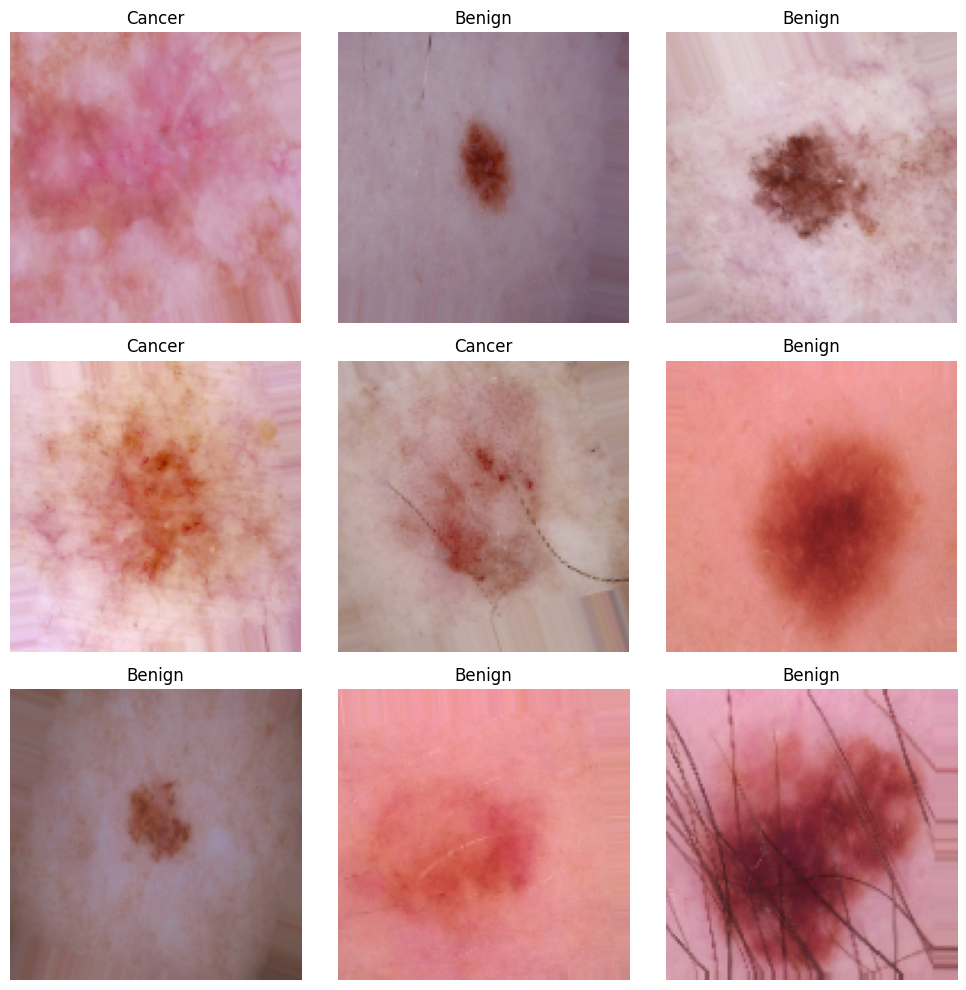

In [22]:
# Preview Training Images

images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(
        "Cancer" if labels[i] else "Benign"
    )
    plt.axis("off")

plt.tight_layout()

plt.show()

In [23]:
# Summary

print("=" * 50)

print("HAM10000 PREPROCESSING COMPLETE")

print("=" * 50)

print(f"Training Images   : {len(train_df)}")
print(f"Validation Images : {len(val_df)}")
print(f"Testing Images    : {len(test_df)}")

print("\nClass Weights: ")

print(class_weights)

print("\nNo lesion leakage detected.")

HAM10000 PREPROCESSING COMPLETE
Training Images   : 7010
Validation Images : 1500
Testing Images    : 1505

Class Weights: 
{0: 0.6213437333806062, 1: 2.560262965668371}

No lesion leakage detected.
